# EDA 
1. Are the labels meaningful?
2. Is there class imbalance?
3. Which features have real signal?
4. Are outliers errors or reality?

## Importing libraries

In [1]:
import pandas as pd 
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt 
import warnings

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

warnings.filterwarnings("ignore")

In [2]:
# Loading model tables
df = pd.read_csv("../outputs/model_table.csv")
df.shape

(25000, 20)

In [3]:
# convert data columns
df['registration_date'] = pd.to_datetime(df['registration_date'],errors='coerce')
df['visit_date'] = pd.to_datetime(df['visit_date'],errors='coerce')
df['billing_date'] = pd.to_datetime(df['billing_date'],errors='coerce')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   patient_id            25000 non-null  int64         
 1   age                   25000 non-null  int64         
 2   gender                25000 non-null  str           
 3   city                  25000 non-null  str           
 4   insurance_provider    25000 non-null  str           
 5   chronic_flag          25000 non-null  int64         
 6   registration_date     25000 non-null  datetime64[us]
 7   visit_id              25000 non-null  int64         
 8   visit_date            25000 non-null  datetime64[us]
 9   department            25000 non-null  str           
 10  visit_type            25000 non-null  str           
 11  length_of_stay_hours  25000 non-null  float64       
 12  risk_score            25000 non-null  str           
 13  doctor_id             25000

In [4]:
df.describe(include="all").T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
patient_id,25000.0,NaN,NaN,NaN,2509.51536,1.0,1249.0,2505.0,3764.0,5000.0,1448.68904
age,25000.0,NaN,NaN,NaN,44.76832,1.0,33.0,45.0,57.0,90.0,17.784232
gender,25000,2,F,12739,NaN,NaN,NaN,NaN,NaN,NaN,NaN
city,25000,6,Hyderabad,4370,NaN,NaN,NaN,NaN,NaN,NaN,NaN
insurance_provider,25000,4,MediCareX,6532,NaN,NaN,NaN,NaN,NaN,NaN,NaN
chronic_flag,25000.0,NaN,NaN,NaN,0.5026,0.0,0.0,1.0,1.0,1.0,0.500003
registration_date,25000,NaN,NaN,NaN,2025-07-18 16:17:11.040000,2025-01-20 00:00:00,2025-04-16 00:00:00,2025-07-19 00:00:00,2025-10-19 00:00:00,2026-01-20 00:00:00,NaN
visit_id,25000.0,NaN,NaN,NaN,12500.5,1.0,6250.75,12500.5,18750.25,25000.0,7217.022701
visit_date,25000,NaN,NaN,NaN,2025-07-21 15:25:51.744000,2025-01-20 00:00:00,2025-04-21 00:00:00,2025-07-21 00:00:00,2025-10-21 00:00:00,2026-01-20 00:00:00,NaN
department,25000,6,General,4228,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Distribution Analysis
## Missing Values Analysis
First thing we always check : What is missing and why

Not all nulls are data errors some are business logic 

In [5]:
# overall null check
df.isnull().sum().sort_values(ascending=False)

approved_amount         1318
payment_days             790
patient_id                 0
age                        0
city                       0
gender                     0
insurance_provider         0
chronic_flag               0
visit_date                 0
department                 0
registration_date          0
visit_id                   0
length_of_stay_hours       0
visit_type                 0
risk_score                 0
doctor_id                  0
billed_amount              0
bill_id                    0
claim_status               0
billing_date               0
dtype: int64

In [6]:
# Focus on key columns
df[['approved_amount','payment_days','length_of_stay_hours']].isnull().sum()

approved_amount         1318
payment_days             790
length_of_stay_hours       0
dtype: int64

## Step 2 - Business Logic Validation

In [7]:
# check A- Paid claims should always have an approved ampunt
# if this returns 0 we are clean
df[
    (df['claim_status'] == 'Paid') &
    (df['approved_amount'].isna())
].shape

(817, 20)

In [8]:
# Check B - payment days missing breakdown by claim status
df[df['payment_days'].isna()]['claim_status'].value_counts()

claim_status
Paid        459
Pending     208
Rejected    123
Name: count, dtype: int64

for pending and rejected claim statuses we can expect the payment days to be null, hoewever for Paid claim status it should not be null and should have a value

In [9]:
# Check C - LOS should never be negative
(df['length_of_stay_hours']<0).sum()

np.int64(0)

## Step 3 - Distribution Analysis

In [11]:
# categorical column reports
print("========== Department ============")
print(df['department'].value_counts())
print("\n============ Visit type=========")
print(df['visit_type'].value_counts())
print("\n============ Insurance Provider============")
print(df['insurance_provider'].value_counts())
print("\n============City==================")
print(df['city'].value_counts())

========== Department ============
department
General        4228
ER             4220
Neurology      4165
Orthopedics    4164
Cardiology     4159
ICU            4064
Name: count, dtype: int64

============ Visit type=========
visit_type
ER     8382
OPD    8381
ICU    8237
Name: count, dtype: int64

============ Insurance Provider============
insurance_provider
MediCareX     6532
CareOne       6283
HealthPlus    6220
SecureLife    5965
Name: count, dtype: int64

============City==================
city
Hyderabad    4370
Pune         4221
Bangalore    4205
Mumbai       4122
Delhi        4107
Chennai      3975
Name: count, dtype: int64


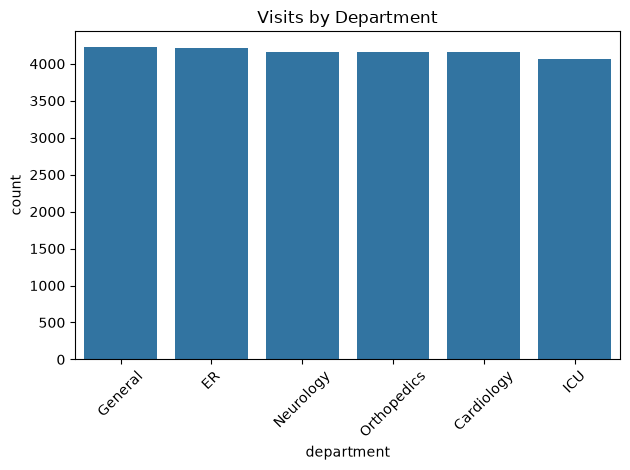

In [14]:
# bar chart showing visits by department
sns.countplot(data=df,x='department',order=df['department'].value_counts().index)
plt.xticks(rotation=45)
plt.title("Visits by Department")
plt.tight_layout()
plt.show()